In [1]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 17.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import math
import random
from itertools import combinations
from itertools import islice
from collections import Counter
from geopy.distance import geodesic
import scipy.spatial.distance as distance
from decimal import Decimal, getcontext
from math import dist
import bz2
import geopandas as gpd
from collections import defaultdict
from google.colab import files
import re
import os
import time
import pickle
import gc
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Verificação Inicial da Base de Dados (Teste de Integridade e Contagem)
Esta célula realiza uma verificação preliminar e exploratória no arquivo de nós brutos (`.nodes.geo`). Seu objetivo principal é contar o número total de linhas do arquivo **sem carregar tudo para a memória RAM**.
Isso é feito iterando sobre o arquivo linha por linha, o que serve como um diagnóstico rápido e eficiente para certificar que o arquivo existe, não está vazio, pode ser acessado corretamente e nos fornece a dimensão real do dataset que vamos processar na etapa de ETL.

In [ ]:
try:
    base_path = '/content/drive/MyDrive/IC - Internet Quântica/'
    file_nodes_geo = os.path.join(base_path, 'kapar-midar-iff.nodes.geo')

    print(f"--- Contando o número total de linhas em: {os.path.basename(file_nodes_geo)} ---")
    print("Isso pode levar um minuto se o arquivo for grande...")

    with open(file_nodes_geo, 'r', errors='ignore') as f:
        for i, _ in enumerate(f, 1):
            pass

    total_linhas = i
    print(f"\nRESULTADO: O arquivo '{os.path.basename(file_nodes_geo)}' tem um total de {total_linhas:,} linhas.")

except NameError:
    total_linhas = 0
    print(f"\nRESULTADO: O arquivo parece estar vazio.")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{file_nodes_geo}'. Verifique o caminho.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

--- Contando o número total de linhas em: kapar-midar-iff.nodes.geo ---
Isso pode levar um minuto se o arquivo for grande...

RESULTADO: O arquivo 'kapar-midar-iff.nodes.geo' tem um total de 58,171,892 linhas.


In [ ]:
try:
    base_path = '/content/drive/MyDrive/IC - Internet Quântica/'
    file_links = os.path.join(base_path, 'kapar-midar-iff.links')

    print(f"--- Contando o número total de linhas em: {os.path.basename(file_links)} ---")
    print("Isso pode levar um minuto se o arquivo for grande...")

    with open(file_links, 'r', errors='ignore') as f:
        for i, _ in enumerate(f, 1):
            pass

    total_linhas = i
    print(f"\nRESULTADO: O arquivo '{os.path.basename(file_links)}' tem um total de {total_linhas:,} linhas.")

except NameError:
    total_linhas = 0
    print(f"\nRESULTADO: O arquivo parece estar vazio.")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{file_links}'. Verifique o caminho.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

--- Contando o número total de linhas em: kapar-midar-iff.links ---
Isso pode levar um minuto se o arquivo for grande...

RESULTADO: O arquivo 'kapar-midar-iff.links' tem um total de 105,503,995 linhas.


In [ ]:
BASE_PATH   = '/content/drive/MyDrive/IC - Internet Quântica/'
FILE_NODES  = os.path.join(BASE_PATH, 'kapar-midar-iff.nodes.geo')
FILE_LINKS  = os.path.join(BASE_PATH, 'kapar-midar-iff.links')

N_DATA_ROWS = 10  # Quantidade de linhas de dados a exibir por arquivo


def separador(titulo: str, largura: int = 80, char: str = '═') -> None:
    """Imprime um separador visual com título centralizado."""
    print(f"\n{'─' * largura}")
    print(f"  {titulo}")
    print(f"{'─' * largura}")


def ler_cabecalho_e_dados(caminho: str, n_dados: int = 10):
    """
    Lê um arquivo linha a linha de forma eficiente (sem carregar tudo na RAM).

    Retorna:
        linhas_comentario (list[str]): linhas do cabeçalho (prefixo '#').
        linhas_dados      (list[str]): primeiras n_dados linhas de dados reais.
    """
    linhas_comentario = []
    linhas_dados      = []
    dados_coletados   = 0

    with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
        for linha in f:
            linha_limpa = linha.rstrip('\r\n')

            if linha_limpa.startswith('#'):
                linhas_comentario.append(linha_limpa)

            elif linha_limpa.strip():
                if dados_coletados < n_dados:
                    linhas_dados.append(linha_limpa)
                    dados_coletados += 1
                else:
                    break
    return linhas_comentario, linhas_dados


def exibir_metadados_arquivo(caminho: str) -> None:
    """Exibe tamanho em disco e nome do arquivo."""
    nome   = os.path.basename(caminho)
    existe = os.path.exists(caminho)
    if existe:
        tamanho_bytes = os.path.getsize(caminho)
        tamanho_gb    = tamanho_bytes / (1024 ** 3)
        print(f"  Arquivo  : {nome}")
        print(f"  Caminho  : {caminho}")
        print(f"  Tamanho  : {tamanho_gb:.2f} GB  ({tamanho_bytes:,} bytes)")
    else:
        print(f"  ⚠ Arquivo não encontrado: {caminho}")


separador("ARQUIVO 1 — kapar-midar-iff.nodes.geo")

exibir_metadados_arquivo(FILE_NODES)

comentarios_nodes, dados_nodes = ler_cabecalho_e_dados(FILE_NODES, N_DATA_ROWS)

# --- Cabeçalho de metadados ---
print(f"\n{'━' * 80}")
print(f"  CABEÇALHO DE METADADOS  ({len(comentarios_nodes)} linha(s) de comentário)")
print(f"{'━' * 80}")
for i, linha in enumerate(comentarios_nodes, 1):
    print(f"  [{i:>3}]  {linha}")

# --- Primeiras linhas de dados → DataFrame ---
print(f"\n{'━' * 80}")
print(f"  PRIMEIRAS {len(dados_nodes)} LINHAS DE DADOS")
print(f"{'━' * 80}")

COLUNAS_NODES = [
    'node_type_id',    # "node.geo N{id}:"
    'continente',      # SA, NA, EU, AS, AF, OC
    'pais',            # código ISO do país
    'regiao',          # código da região/estado
    'cidade',          # nome da cidade
    'latitude',        # grau decimal
    'longitude',       # grau decimal
    'info_extra',      # ex: população
    'vazio',           # coluna sem dados (dupla tabulação)
    'metodo',          # método de geolocalização (ddec, maxmind, ix)
]

registros_nodes = []
for linha in dados_nodes:
    campos = linha.split('\t')
    # Padeia com None se uma linha tiver menos colunas que o esperado
    while len(campos) < len(COLUNAS_NODES):
        campos.append(None)
    registros_nodes.append(campos[:len(COLUNAS_NODES)])

df_nodes_preview = pd.DataFrame(registros_nodes, columns=COLUNAS_NODES)

# Formata o node_type_id para extrair apenas o ID numérico na exibição
df_nodes_preview.insert(
    0, 'node_id',
    df_nodes_preview['node_type_id']
        .str.replace('node.geo N', '', regex=False)
        .str.replace(':', '', regex=False)
        .str.strip()
)
df_nodes_preview.drop(columns=['node_type_id'], inplace=True)

pd.set_option('display.max_columns',  None)
pd.set_option('display.width',        200)
pd.set_option('display.max_colwidth', 30)

print(df_nodes_preview.to_string(index=True))

# --- Resumo dos tipos ---
print(f"\n{'━' * 80}")
print("  TIPOS DAS COLUNAS (dados brutos — todos lidos como string)")
print(f"{'━' * 80}")
print(df_nodes_preview.dtypes.to_string())
print(f"\n  Shape da amostra: {df_nodes_preview.shape[0]} linhas × {df_nodes_preview.shape[1]} colunas")
print(f"  (O arquivo completo possui ~58.171.887 linhas de dados)")

separador("ARQUIVO 2 — kapar-midar-iff.links")

exibir_metadados_arquivo(FILE_LINKS)

comentarios_links, dados_links = ler_cabecalho_e_dados(FILE_LINKS, N_DATA_ROWS)

# --- Cabeçalho de metadados (resumido: primeiras e últimas linhas) ---
MAX_EXIBIR = 50

print(f"\n{'━' * 80}")
print(f"  CABEÇALHO DE METADADOS  ({len(comentarios_links)} linha(s) de comentário)")
print(f"{'━' * 80}")

if len(comentarios_links) <= MAX_EXIBIR:
    for i, linha in enumerate(comentarios_links, 1):
        print(f"  [{i:>4}]  {linha}")
else:
    metade = MAX_EXIBIR // 2
    for i, linha in enumerate(comentarios_links[:metade], 1):
        print(f"  [{i:>4}]  {linha}")
    print(f"\n  ... ({len(comentarios_links) - MAX_EXIBIR} linhas omitidas) ...\n")
    inicio_fim = len(comentarios_links) - metade
    for i, linha in enumerate(comentarios_links[inicio_fim:], inicio_fim + 1):
        print(f"  [{i:>4}]  {linha}")

# --- Primeiras linhas de dados (formato livre) ---
print(f"\n{'━' * 80}")
print(f"  PRIMEIRAS {len(dados_links)} LINHAS DE DADOS  (formato bruto — N variável de tokens por linha)")
print(f"{'━' * 80}")

if dados_links:
    for i, linha in enumerate(dados_links, 1):
        # Trunca linhas muito longas para não poluir a tela
        exibicao = linha if len(linha) <= 120 else linha[:117] + '...'
        print(f"  [{i:>2}]  {exibicao}")

    # Análise rápida do padrão de nós por linha
    import re
    node_pattern = re.compile(r'N\d+')
    print(f"\n{'━' * 80}")
    print("  ANÁLISE DA ESTRUTURA — nós identificados por linha (padrão N\\d+)")
    print(f"{'━' * 80}")
    print(f"  {'Linha':<6}  {'Nós encontrados':<50}  {'Qtd pares'}")
    print(f"  {'─'*5}  {'─'*49}  {'─'*10}")
    from itertools import combinations
    for i, linha in enumerate(dados_links, 1):
        nos = node_pattern.findall(linha)
        n_pares = len(list(combinations(nos, 2))) if len(nos) > 1 else 0
        nos_str = ', '.join(nos[:8]) + (' ...' if len(nos) > 8 else '')
        print(f"  [{i:>2}]    {nos_str:<50}  {n_pares} par(es)")
else:
    print("  ⚠ Nenhuma linha de dados encontrada no trecho lido.")
    print("    O arquivo .links pode ser composto apenas por cabeçalho neste fragmento.")


separador("RESUMO COMPARATIVO DOS ARQUIVOS BRUTOS")

resumo = pd.DataFrame({
    'Arquivo': ['kapar-midar-iff.nodes.geo', 'kapar-midar-iff.links'],
    'Tamanho': ['3,7 GB', '4,5 GB'],
    'Formato': ['TSV (\\t)', 'Texto livre'],
    'Linhas comentário (#)': [len(comentarios_nodes), len(comentarios_links)],
    'Colunas (dados)': ['10 fixas', 'N variável'],
    'Separador': ['Tab (\\t)', 'Espaço / misto'],
    'Total linhas (arquivo completo)': ['~58.171.887', '~dezenas de M'],
})

print(resumo.to_string(index=False))
print()


────────────────────────────────────────────────────────────────────────────────
  ARQUIVO 1 — kapar-midar-iff.nodes.geo
────────────────────────────────────────────────────────────────────────────────
  Arquivo  : kapar-midar-iff.nodes.geo
  Caminho  : /content/drive/MyDrive/IC - Internet Quântica/kapar-midar-iff.nodes.geo
  Tamanho  : 3.45 GB  (3,699,172,534 bytes)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CABEÇALHO DE METADADOS  (5 linha(s) de comentário)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [  1]  # exe:merge-itdk.pl
  [  2]  # path:./
  [  3]  #     arg:kapar-midar-iff.nodes.geo_ddec
  [  4]  #     arg:kapar-midar-iff.nodes.geo_ix
  [  5]  #     arg:kapar-midar-iff.nodes.geo_maxmind

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PRIMEIRAS 10 LINHAS DE DADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  node_id continente

### Extração e Leitura Fracionada de Links (Streaming e Batching)
Os arquivos `.links` do CAIDA são extensos e sua leitura sobrecarregaria rapidamente a memória da máquinas domésticas com recursos computacionais limitados. Para contornar isso, esta célula implementa um mecanismo de **Engenharia de Dados baseado em fluxo (Streaming)**:
1. **Gerador `gerar_links_robusto`**: Lê o arquivo de texto linha por linha. Utiliza expressões regulares (Regex) para identificar os nós (padrão `N\d+`) conectados na mesma linha. Ele entrega combinações de pares de nós como gerador (`yield`), economizando RAM.
2. **Processamento em Lotes (Batching)**: As arestas são agrupadas em blocos (batches) de 500.000 registros e transformadas em DataFrames temporários.
3. **Consolidação**: Ao final, todos os blocos são concatenados num único DataFrame (`df_links`) e as arestas duplicadas são removidas, resultando numa lista de adjacência (EdgeList) limpa e pronta para modelagem topológica.

In [4]:
def gerar_links_robusto(caminho_do_arquivo, limite_de_linhas=None):

    print(f"Iniciando leitura 'streaming' do arquivo de links: {os.path.basename(caminho_do_arquivo)}...")

    node_pattern = re.compile(r'(N\d+)')
    linhas_lidas = 0

    try:
        with open(caminho_do_arquivo, 'r', errors='ignore') as f:
            for line in f:
                if limite_de_linhas and linhas_lidas >= limite_de_linhas:
                    print(f"-> Limite de {limite_de_linhas:,} linhas de leitura atingido.")
                    break

                linhas_lidas += 1

                if line.startswith('#') or not line.strip():
                    continue

                nodes_on_this_link = node_pattern.findall(line)

                if len(nodes_on_this_link) > 1:
                    for node1, node2 in combinations(nodes_on_this_link, 2):
                        yield {'inicial_node': node1, 'final_node': node2}

    except FileNotFoundError:
        print(f"ERRO: Arquivo não encontrado em '{caminho_do_arquivo}'")
        yield from ()


base_path = '/content/drive/MyDrive/IC - Internet Quântica/'
file_edges = os.path.join(base_path, 'kapar-midar-iff.links')
limite_de_linhas = 1600000

BATCH_SIZE = 500_000

lista_de_dataframes = []
batch_de_arestas = []
total_arestas_processadas = 0

print(f"Processando links em lotes de {BATCH_SIZE:,} arestas...")

for aresta in gerar_links_robusto(file_edges, limite_de_linhas=limite_de_linhas):
    batch_de_arestas.append(aresta)

    if len(batch_de_arestas) >= BATCH_SIZE:
        lista_de_dataframes.append(pd.DataFrame(batch_de_arestas))

        batch_de_arestas = []

        total_arestas_processadas = len(lista_de_dataframes) * BATCH_SIZE
        print(f"  -> Lote processado. Total de arestas até agora: {total_arestas_processadas:,}")

if batch_de_arestas:
    lista_de_dataframes.append(pd.DataFrame(batch_de_arestas))
    print(f"  -> Processando lote final.")

print("\nConcatenando todos os lotes em um DataFrame final...")
if lista_de_dataframes:
    df_links = pd.concat(lista_de_dataframes, ignore_index=True)

    print("Removendo duplicatas...")
    df_links.drop_duplicates(inplace=True)

    print("\n--- Processo Finalizado ---")
    print("\nAmostra do DataFrame de Links (Edgelist) criado:")
    print(df_links.head())
    print("\nInformações do DataFrame:")
    df_links.info()
else:
    print("Nenhuma aresta foi gerada.")

Processando links em lotes de 500,000 arestas...
Iniciando leitura 'streaming' do arquivo de links: kapar-midar-iff.links...
  -> Lote processado. Total de arestas até agora: 500,000
  -> Lote processado. Total de arestas até agora: 1,000,000
  -> Lote processado. Total de arestas até agora: 1,500,000
  -> Lote processado. Total de arestas até agora: 2,000,000
  -> Lote processado. Total de arestas até agora: 2,500,000
  -> Lote processado. Total de arestas até agora: 3,000,000
  -> Lote processado. Total de arestas até agora: 3,500,000
  -> Lote processado. Total de arestas até agora: 4,000,000
  -> Lote processado. Total de arestas até agora: 4,500,000
  -> Lote processado. Total de arestas até agora: 5,000,000
  -> Lote processado. Total de arestas até agora: 5,500,000
  -> Lote processado. Total de arestas até agora: 6,000,000
  -> Lote processado. Total de arestas até agora: 6,500,000
  -> Lote processado. Total de arestas até agora: 7,000,000
  -> Lote processado. Total de aresta

### Inspeção Diagnóstica de Dados Brutos (Troubleshooting)
Esta célula atua como uma ferramenta de diagnóstico e auditoria dos dados primários.
O código abre o arquivo `.nodes.geo` no modo de leitura nativa do Python e imprime a representação literal (`repr()`) das 200 primeiras linhas de dados úteis (ignorando os cabeçalhos comentados com `#`). Esse procedimento metodológico foi crítico para auditar os separadores de tabulação (`\t`) e identificar campos vazios e valores NaN no arquivo.

In [ ]:
base_path = '/content/drive/MyDrive/IC - Internet Quântica/'
file_nodes_geo = os.path.join(base_path, 'kapar-midar-iff.nodes.geo')

print("--- 200 Primeiras linhas reais do arquivo ---")
with open(file_nodes_geo, 'r') as f:
    contador = 0
    for linha in f:
        if not linha.startswith('#'):
            print(repr(linha))
            contador += 1
            if contador == 200:
                break

--- 200 Primeiras linhas reais do arquivo ---
'node.geo N4:\tSA\tCO\t34\tBogota\t4.60971\t-74.08175\t7674366\t\tddec\n'
'node.geo N5:\tNA\tUS\tNY\tHicksville\t40.76843\t-73.52513\t41547\t\tddec\n'
'node.geo N13:\tSA\tUY\t10\tDepartamento de Montevideo\t-34.82500\t-56.20000\t1324115\t\tddec\n'
'node.geo N17:\tSA\tCO\t34\tBogota\t4.60971\t-74.08175\t7674366\t\tddec\n'
'node.geo N19:\tSA\tCO\t34\tBogota\t4.60971\t-74.08175\t7674366\t\tddec\n'
'node.geo N20:\tSA\tCO\t34\tBogota\t4.60971\t-74.08175\t7674366\t\tddec\n'
'node.geo N21:\tSA\tUY\t10\tDepartamento de Montevideo\t-34.82500\t-56.20000\t1324115\t\tddec\n'
'node.geo N23:\tSA\tCO\t34\tBogota\t4.60971\t-74.08175\t7674366\t\tddec\n'
'node.geo N24:\tSA\tUY\t10\tDepartamento de Montevideo\t-34.82500\t-56.20000\t1324115\t\tddec\n'
'node.geo N26:\tSA\tCO\t34\tBogota\t4.60971\t-74.08175\t7674366\t\tddec\n'
'node.geo N28:\tSA\tUY\t10\tDepartamento de Montevideo\t-34.82500\t-56.20000\t1324115\t\tddec\n'
'node.geo N29:\tSA\tUY\t10\tDepartamento

### Extração Topológica e Pré-Processamento Otimizado (ETL)
Esta célula é responsável por processar o arquivo de metadados geográficos e mapeá-los sobre as ligações lógicas da rede. Devido aos limites computacionais de memória (RAM) e anomalias do interpretador, a extração exige quatro camadas de otimização estrutural:

1. **Mitigação de Anomalias Categóricas:** Por padrão, o Pandas categoriza a string 'NA' (América do Norte) como um dado faltante (*Not Available*). Para proteger a integridade geoeconômica da rede, implementou-se o parâmetro `na_filter=False` combinado à tipagem textual estrita (`dtype=str`), forçando o interpretador a respeitar o dado bruto.
2. **Leitura Fracionada e Gestão de Memória (*Chunking*):** O arquivo é consumido num fluxo de blocos iteráveis de 500.000 linhas. Cada bloco é isolado, processado e destruído (através do `gc.collect()`), garantindo que a RAM permaneça estável durante todo o processo.
3. **Conversão Volumétrica e Limpeza (*Downcasting*):** As propriedades que sobrevivem ao filtro de continente vazio são rigorosamente tipificadas para poupar bytes: as coordenadas geográficas são convertidas em `float32`, textos repetitivos em `category`, e os IDs brutos são eliminados via expressões regulares para se tornarem inteiros leves.
4. **Mapeamento Topológico Bidirecional:** Ao final da consolidação, o código indexa geograficamente os roteadores e utiliza a função de mapeamento vetorizado (`.map()`) para transferir as coordenadas e continentes simultaneamente para o nó de origem e para o nó de destino no grafo de links. Ligações órfãs são eliminadas, gerando o Grafo Estrutural Base (`df_final`).

In [ ]:
colunas_geo = [
    'raw_node_id', 'continente', 'pais', 'regiao', 'cidade',
    'latitude', 'longitude', 'info_extra', 'vazio', 'metodo'
]

print("Iniciando leitura otimizada do arquivo .nodes.geo...")

colunas_usadas = ['raw_node_id', 'continente', 'pais', 'latitude', 'longitude']

tipos_dados = {
    'continente': 'category',
    'pais': 'category',
    'latitude': 'float32',
    'longitude': 'float32'
}
pedacos_globais = []
total_linhas_processadas = 0

for chunk in pd.read_csv(file_nodes_geo, sep='\t', names=colunas_geo,
                         usecols=colunas_usadas, comment='#', chunksize=500000,
                         na_filter=False, dtype=str):

    total_linhas_processadas += len(chunk)

    chunk_valido = chunk[chunk['continente'] != ''].copy()

    if not chunk_valido.empty:
        chunk_valido['raw_node_id'] = chunk_valido['raw_node_id'].str.replace('node.geo N', '', regex=False)
        chunk_valido['raw_node_id'] = chunk_valido['raw_node_id'].str.replace(':', '', regex=False)
        chunk_valido['raw_node_id'] = pd.to_numeric(chunk_valido['raw_node_id'], downcast='unsigned')

        chunk_valido['latitude'] = pd.to_numeric(chunk_valido['latitude'], errors='coerce').astype('float32')
        chunk_valido['longitude'] = pd.to_numeric(chunk_valido['longitude'], errors='coerce').astype('float32')

        chunk_valido['continente'] = chunk_valido['continente'].astype('category')
        chunk_valido['pais'] = chunk_valido['pais'].astype('category')

        pedacos_globais.append(chunk_valido)

    del chunk, chunk_valido
    gc.collect()

print(f"Processamento concluído. {total_linhas_processadas} linhas analisadas no total.")
df_nodes = pd.concat(pedacos_globais, ignore_index=True)

del pedacos_globais
gc.collect()

df_nodes.set_index('raw_node_id', inplace=True)

# 1. Limpa o prefixo e os dois pontos
print("Preparando as ligações globais (df_links)...")
df_links['inicial_node'] = df_links['inicial_node'].astype(str).str.replace('N', '', regex=False)
df_links['final_node'] = df_links['final_node'].astype(str).str.replace('N', '', regex=False)
gc.collect()

# Transformamos o ID em índice para o mapeamento ser ultra-rápido
df_links['inicial_node'] = pd.to_numeric(df_links['inicial_node'], downcast='unsigned')
df_links['final_node'] = pd.to_numeric(df_links['final_node'], downcast='unsigned')
gc.collect()

print("Mapeando propriedades dos nós de Origem...")
df_links['continent_inicial'] = df_links['inicial_node'].map(df_nodes['continente'])
df_links['country_inicial']   = df_links['inicial_node'].map(df_nodes['pais'])
df_links['latitude_inicial']  = df_links['inicial_node'].map(df_nodes['latitude'])
df_links['longitude_inicial'] = df_links['inicial_node'].map(df_nodes['longitude'])

print("Mapeando propriedades dos nós de Destino...")
df_links['continent_final'] = df_links['final_node'].map(df_nodes['continente'])
df_links['country_final']   = df_links['final_node'].map(df_nodes['pais'])
df_links['latitude_final']  = df_links['final_node'].map(df_nodes['latitude'])
df_links['longitude_final'] = df_links['final_node'].map(df_nodes['longitude'])

df_links.dropna(subset=['continent_inicial', 'continent_final'], inplace=True)

df_links['inicial_node'] = 'N' + df_links['inicial_node'].astype(str)
df_links['final_node']   = 'N' + df_links['final_node'].astype(str)

colunas_csv = [
    'inicial_node', 'final_node',
    'continent_inicial', 'country_inicial', 'latitude_inicial', 'longitude_inicial',
    'continent_final', 'country_final', 'latitude_final', 'longitude_final'
]

df_final = df_links[colunas_csv]

print("df_final gerado com sucesso!")

In [ ]:
df_nodes

,continente,pais,latitude,longitude
raw_node_id,,,,
4,SA,CO,4.609710,-74.081749
5,NA,US,40.768429,-73.525131
13,SA,UY,-34.825001,-56.200001
17,SA,CO,4.609710,-74.081749
19,SA,CO,4.609710,-74.081749
...,...,...,...,...
102301717,AS,ID,-0.031000,109.325699
102301718,AS,ID,-0.031000,109.325699
102301719,AS,ID,-0.031000,109.325699


In [ ]:
### Manter apenas as colunas

nodes_sa = df_final.loc[df_final["continent_inicial"] == "SA"]
nodes_eu = df_final.loc[df_final["continent_inicial"] == "EU"]
nodes_as = df_final.loc[df_final["continent_inicial"] == "AS"]
nodes_af = df_final.loc[df_final["continent_inicial"] == "AF"]
nodes_oc = df_final.loc[df_final["continent_inicial"] == "OC"]
nodes_na = df_final.loc[df_final["continent_inicial"] == "NA"]

nodes_na



### Exportação dos Dados Segmentados para Arquivos CSV
Esta célula tem o objetivo de persistir e gravar em disco (arquivos físicos `.csv`) as tabelas de arestas limpas e purificadas de cada continente. Estes arquivos funcionarão como os *checkpoints* tabulares do pré-processamento, facilitando o acesso direto na etapa de geração do grafo sem a necessidade de reprocessar a base bruta global.

In [ ]:
continentes = ['NA', 'EU', 'AS', 'SA', 'AF', 'OC']

for cont in continentes:

    df_continente = df_final[(df_final['continent_inicial'] == cont) & (df_final['continent_final'] == cont)]

    if not df_continente.empty:
        nome_ficheiro = f'nodes_{cont}.csv'

        df_continente.to_csv(nome_ficheiro, index=False)

        print(f"-> Ficheiro {nome_ficheiro} gerado com {len(df_continente)} ligações.")

        files.download(nome_ficheiro)

        # Uma pequena pausa para evitar que o navegador bloqueie múltiplos downloads em simultâneo
        time.sleep(2)
    else:
        print(f"-> Aviso: Não foram encontradas ligações válidas para o continente {cont}.")

print("\nProcesso concluído!")

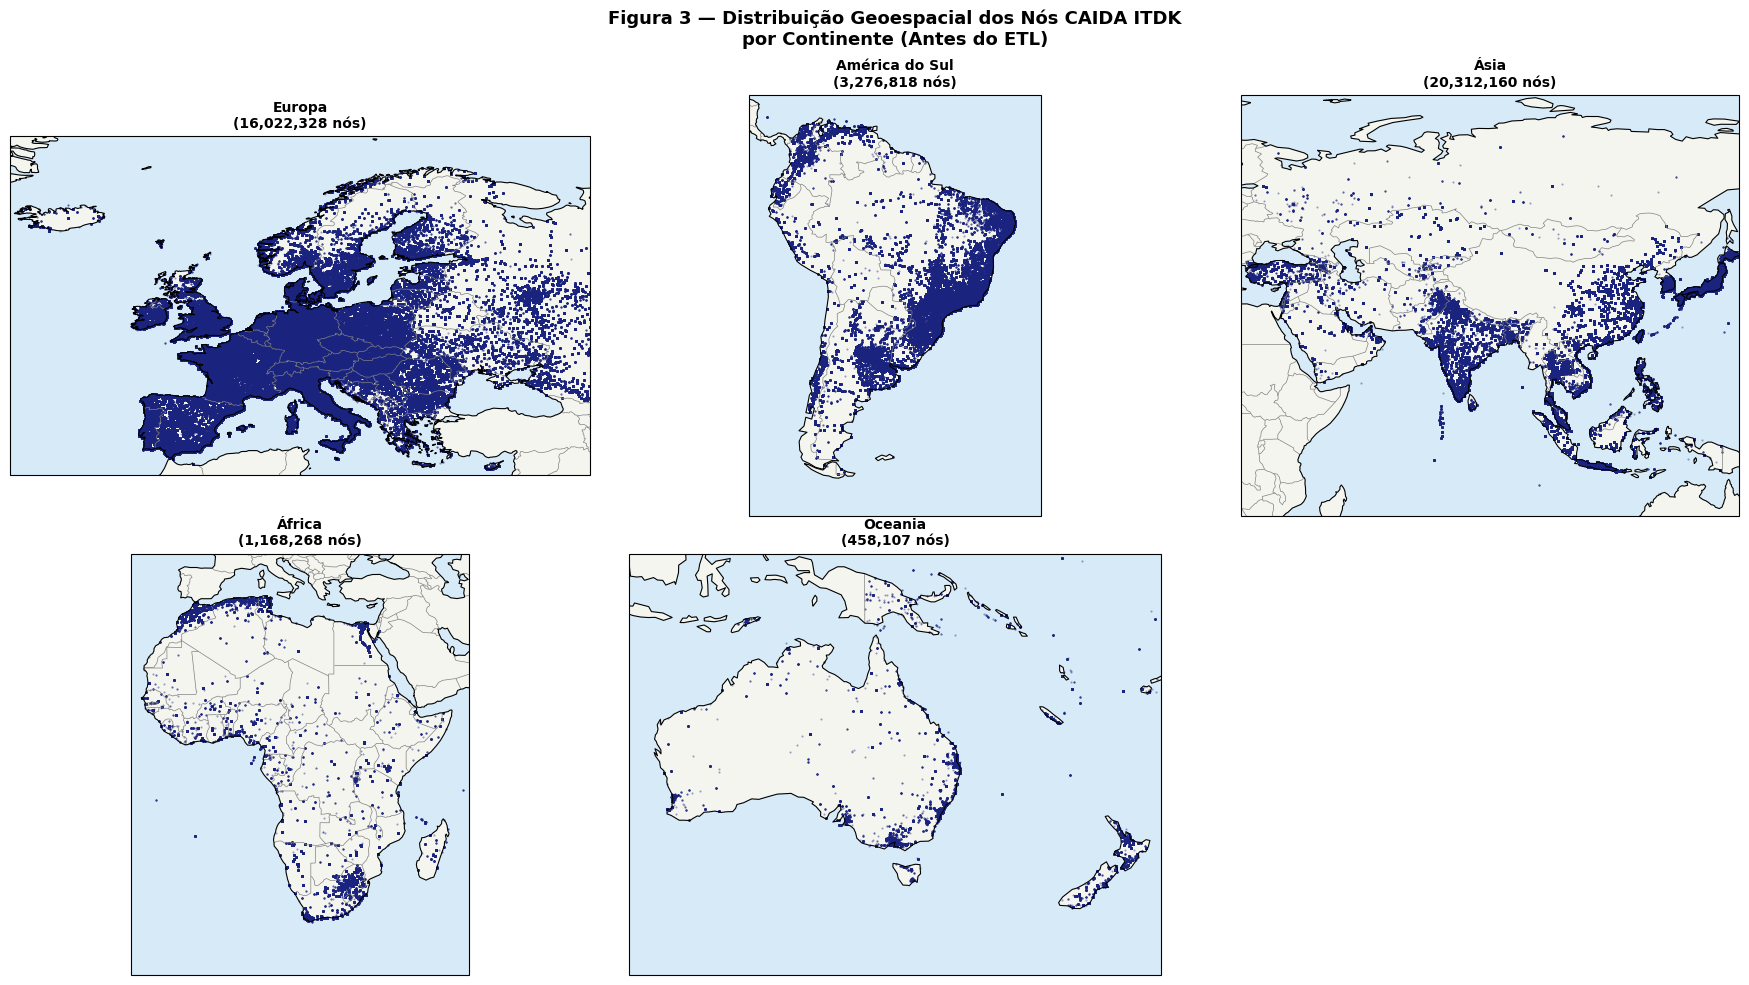

In [ ]:
# df_nodes já foi gerado na Fase 1
# Filtrar por continente
continentes = {
    'EU': (-25, 45, 34, 72, 'Europa'),
    'SA': (-85, -30, -60, 15, 'América do Sul'),
    'AS': (25, 145, -10, 75, 'Ásia'),
    'AF': (-20, 55, -40, 40, 'África'),
    'OC': (110, 180, -50, 0, 'Oceania'),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10),subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for idx, (cod, (lon0, lon1, lat0, lat1, nome)) in enumerate(continentes.items()):
    ax = axes[idx]
    df_cont = df_nodes[df_nodes['continente'] == cod]

    ax.set_extent([lon0, lon1, lat0, lat1])
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F0')
    ax.add_feature(cfeature.OCEAN, facecolor='#D6EAF8')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    ax.scatter(df_cont['longitude'], df_cont['latitude'],
               s=0.3, c='#1A237E', alpha=0.4, transform=ccrs.PlateCarree())

    ax.set_title(f"{nome}\n({len(df_cont):,} nós)", fontsize=10, fontweight='bold')

# Ocultar o 6º subplot (NA já existe separada)
axes[5].set_visible(False)

plt.suptitle("Figura 3 — Distribuição Geoespacial dos Nós CAIDA ITDK\n"
             "por Continente (Antes do ETL)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig3_nodes_distribution.pdf", dpi=300, bbox_inches='tight')